# Week 9-10: Model Evaluation and Preprocessing

**Model evaluation:** train/test split, cross-validation, confusion matrix, precision / recall / F1, ROC-AUC  
**Preprocessing:** feature engineering and scaling, handling missing data

Name: Your Name | Roll No: ______

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)

## 1. The data

Problem: predict whether a student **passes (1) or fails (0)** from hours studied and attendance %.
The data is made up. Some values are deliberately removed to create **missing data**.

In [2]:
rng = np.random.default_rng(11)
n = 100
passed = rng.integers(0, 2, n)
hours = np.clip(np.where(passed == 1, 6.5, 3.5) + rng.normal(0, 1.8, n), 0, 10)
attendance = np.clip(np.where(passed == 1, 80, 58) + rng.normal(0, 12, n), 30, 100)

df = pd.DataFrame({"hours": hours, "attendance": attendance, "passed": passed})
df.loc[rng.random(n) < 0.12, "hours"] = np.nan        # make some values missing
df.loc[rng.random(n) < 0.15, "attendance"] = np.nan
df.head(8)

,hours,attendance,passed
0,NaN,60.704149,0
1,4.979464,71.013707,0
2,7.629278,86.934367,1
3,4.223073,50.277272,0
4,8.220205,71.314681,1
5,NaN,100.000000,1
6,7.605073,89.079655,1
7,4.584998,NaN,0


## 2. Missing data
First check how much is missing.

In [3]:
print(df.isna().sum())
print("Rows with any missing value:", df.isna().any(axis=1).sum(), "out of", len(df))

hours         14
attendance     8
passed         0
dtype: int64
Rows with any missing value: 22 out of 100


Three simple ways to handle it:
- **Drop** rows with missing values (simple, but we lose data)
- **Fill with the mean**
- **Fill with the median** (better when there are outliers)

Important: the fill value must be calculated from the **training data only**, otherwise information from the test data leaks in
(data leakage). A scikit-learn `Pipeline` does this for us automatically.

## 3. Train/test split
We keep 25% of the data aside. The model never sees it while training.
`stratify` keeps the same pass/fail ratio in both parts.

In [4]:
X = df[["hours", "attendance"]]
y = df["passed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 75 | Test rows: 25


In [5]:
# builds: [missing value handling] -> [scaling] -> [logistic regression]
def build_pipeline(missing="mean", scaling="standard"):
    steps = []
    if missing in ("mean", "median"):
        steps.append(("impute", SimpleImputer(strategy=missing)))
    if scaling == "minmax":
        steps.append(("scale", MinMaxScaler()))
    elif scaling == "standard":
        steps.append(("scale", StandardScaler()))
    steps.append(("model", LogisticRegression(max_iter=1000)))
    return Pipeline(steps)

def fit_and_score(missing, scaling, X_train, X_test, y_train, y_test):
    if missing == "drop":                       # drop rows (train and test separately)
        X_train = X_train.dropna(); y_train = y_train.loc[X_train.index]
        X_test = X_test.dropna();   y_test = y_test.loc[X_test.index]
    model = build_pipeline(missing, scaling).fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    return model, probs, y_test

## 4. Comparing missing-data methods and scaling
Every combination of missing-data method and scaling, tested on the same split.

In [6]:
rows = []
for missing in ["drop", "mean", "median"]:
    for scaling in ["none", "minmax", "standard"]:
        model, probs, yt = fit_and_score(missing, scaling, X_train, X_test, y_train, y_test)
        rows.append({"Missing values": missing, "Scaling": scaling,
                     "Test accuracy": round(accuracy_score(yt, probs >= 0.5), 3),
                     "Test ROC-AUC": round(roc_auc_score(yt, probs), 3)})
pd.DataFrame(rows)

,Missing values,Scaling,Test accuracy,Test ROC-AUC
0,drop,none,0.909,0.967
1,drop,minmax,0.909,0.967
2,drop,standard,0.909,0.967
3,mean,none,0.920,0.968
4,mean,minmax,0.920,0.974
5,mean,standard,0.920,0.968
6,median,none,0.920,0.968
7,median,minmax,0.920,0.974
8,median,standard,0.920,0.968


**Note:** scaling matters most for distance-based and gradient-based models (KNN, SVM, neural networks).
Scikit-learn's Logistic Regression copes fairly well with unscaled data, so the scores here may not change much.
We still scale because it is good practice, and it makes the weights comparable.

In [7]:
# what does the data look like after filling with the mean and standardising?
model, probs, yt = fit_and_score("mean", "standard", X_train, X_test, y_train, y_test)
print("Fill values (training means):", model.named_steps["impute"].statistics_.round(2))
pd.DataFrame(model[:-1].transform(X_train.head(5)), columns=X.columns).round(2)

Fill values (training means): [ 5.33 69.92]


,hours,attendance
0,-0.07,1.11
1,0.00,1.23
2,0.25,-1.41
3,0.99,0.00
4,1.66,1.14


## 5. Feature engineering
Creating new columns from old ones that might help the model:
- `effort = hours x attendance / 100`
- `hours_squared = hours²`

In [8]:
def add_features(data):
    data = data.copy()
    data["effort"] = data["hours"] * data["attendance"] / 100
    data["hours_squared"] = data["hours"] ** 2
    return data

Xe_train, Xe_test = add_features(X_train), add_features(X_test)

_, p_old, yt = fit_and_score("mean", "standard", X_train, X_test, y_train, y_test)
_, p_new, yt2 = fit_and_score("mean", "standard", Xe_train, Xe_test, y_train, y_test)
pd.DataFrame({"Features": ["hours, attendance", "+ effort, hours_squared"],
              "Test accuracy": [round(accuracy_score(yt, p_old >= 0.5), 3), round(accuracy_score(yt2, p_new >= 0.5), 3)],
              "Test ROC-AUC": [round(roc_auc_score(yt, p_old), 3), round(roc_auc_score(yt2, p_new), 3)]})

,Features,Test accuracy,Test ROC-AUC
0,"hours, attendance",0.92,0.968
1,"+ effort, hours_squared",0.92,0.968


## 6. Model evaluation
We use the pipeline with **mean fill + standardisation** from here on.

### Confusion matrix
|  | Predicted Pass | Predicted Fail |
|---|---|---|
| **Actual Pass** | TP (true positive) | FN (false negative) |
| **Actual Fail** | FP (false positive) | TN (true negative) |

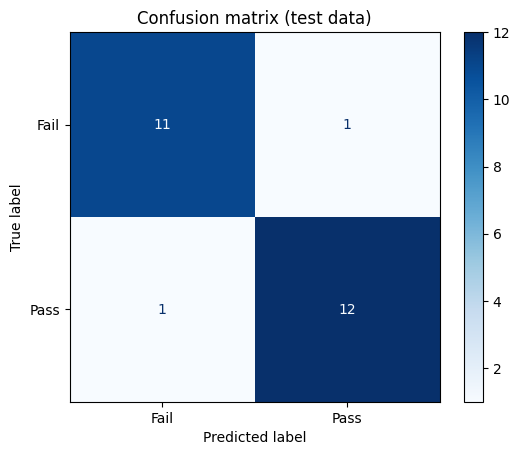

In [9]:
model, probs, yt = fit_and_score("mean", "standard", X_train, X_test, y_train, y_test)
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(yt, preds)
ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"]).plot(cmap="Blues")
plt.title("Confusion matrix (test data)")
plt.show()

### Accuracy, Precision, Recall, F1

- **Accuracy** = (TP + TN) / total
- **Precision** = TP / (TP + FP): of the students predicted Pass, how many really passed
- **Recall** = TP / (TP + FN): of the students who really passed, how many we found
- **F1** = 2 x Precision x Recall / (Precision + Recall)

In [10]:
tn, fp, fn, tp = cm.ravel()
print("TP =", tp, "| FP =", fp, "| FN =", fn, "| TN =", tn)
print()
print("Accuracy :", round(accuracy_score(yt, preds), 3))
print("Precision:", round(precision_score(yt, preds), 3))
print("Recall   :", round(recall_score(yt, preds), 3))
print("F1 score :", round(f1_score(yt, preds), 3))
print("Check precision by hand:", round(tp / (tp + fp), 3))

TP = 12 | FP = 1 | FN = 1 | TN = 11

Accuracy : 0.92
Precision: 0.923
Recall   : 0.923
F1 score : 0.923
Check precision by hand: 0.923


### Effect of the threshold
By default we predict Pass when the probability is at least 0.5. Changing it trades precision against recall.

In [11]:
rows = []
for t in [0.2, 0.3, 0.5, 0.7, 0.8]:
    p = (probs >= t).astype(int)
    rows.append({"Threshold": t, "Precision": round(precision_score(yt, p, zero_division=0), 3),
                 "Recall": round(recall_score(yt, p), 3), "F1": round(f1_score(yt, p), 3)})
pd.DataFrame(rows)

,Threshold,Precision,Recall,F1
0,0.2,0.765,1.000,0.867
1,0.3,0.923,0.923,0.923
2,0.5,0.923,0.923,0.923
3,0.7,1.000,0.769,0.870
4,0.8,1.000,0.692,0.818


### ROC curve and AUC
The ROC curve plots the true positive rate against the false positive rate for **every** threshold.
AUC is the area under it: 0.5 means random guessing, 1.0 means perfect.

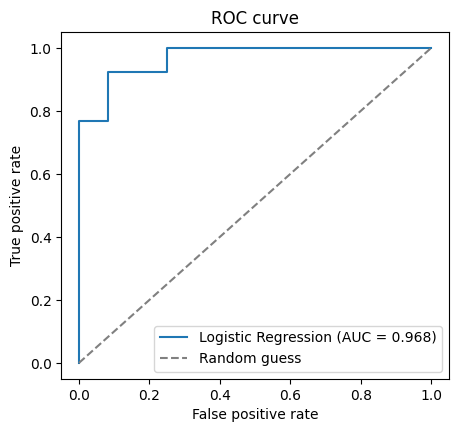

In [12]:
fpr, tpr, _ = roc_curve(yt, probs)
auc = roc_auc_score(yt, probs)

plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curve"); plt.legend()
plt.show()

## 7. Cross-validation
One train/test split can be lucky or unlucky. **K-fold cross-validation** splits the data into k parts and uses each part once as the test set.
The mean over the folds is more reliable, and the standard deviation shows how stable the score is.
Because we use a Pipeline, the filling and scaling are redone inside every fold (no leakage).

In [13]:
X_all = df[["hours", "attendance"]]
y_all = df["passed"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(build_pipeline("mean", "standard"), X_all, y_all, cv=cv,
                        scoring=["accuracy", "f1", "roc_auc"])
cv_table = pd.DataFrame({"Accuracy": scores["test_accuracy"], "F1": scores["test_f1"], "ROC-AUC": scores["test_roc_auc"]},
                        index=[f"Fold {i}" for i in range(1, 6)])
cv_table.loc["Mean"] = cv_table.mean()
cv_table.loc["Std dev"] = cv_table.iloc[:5].std(ddof=0)
cv_table.round(3)

,Accuracy,F1,ROC-AUC
Fold 1,0.95,0.947,0.990
Fold 2,0.85,0.842,0.960
Fold 3,0.85,0.857,0.960
Fold 4,0.90,0.900,0.949
Fold 5,0.85,0.880,0.980
Mean,0.88,0.885,0.968
Std dev,0.04,0.037,0.015


## Conclusion

| Topic | What we learned |
|---|---|
| Train/test split | Judge the model on data it has never seen |
| Cross-validation | Gives a more reliable score than a single split |
| Confusion matrix | Shows exactly which mistakes the model makes (FP vs FN) |
| Precision / Recall / F1 | Better than accuracy alone, and the threshold trades one for the other |
| ROC-AUC | Measures ranking quality across all thresholds |
| Missing data | Drop, mean or median. Learn the fill value from training data only |
| Scaling | Puts features on a similar range. Important for KNN, SVM, neural nets |
| Feature engineering | New columns made from old ones can help the model |